get dataset from drive


In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# !unzip -q "/content/drive/MyDrive/Chilli-leaf-disease-dataset/Chili-Leaf-Disease-Augmented-Dataset.zip" -d "/content/chili_dataset"

# !ls "/content/chili_dataset"

'Chili Leaf Disease Augmented Dataset'


Main

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications.resnet50 import preprocess_input

In [4]:
data_path = '/content/chili_dataset/Chili Leaf Disease Augmented Dataset'

datagen = ImageDataGenerator(preprocessing_function=preprocess_input, validation_split=0.2) # 12000 images

training_data = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='training')

validation_data = datagen.flow_from_directory(data_path, target_size=(224, 224), batch_size=32, class_mode='categorical', subset='validation')

print(f"\nCategories found: ")
for i in training_data.class_indices.keys():
  print(i)

Found 9600 images belonging to 6 classes.
Found 2400 images belonging to 6 classes.

Categories found: 
Bacterial Spot
Cercospora Leaf Spot
Curl Virus
Healthy Leaf
Nutrition Deficiency
White spot


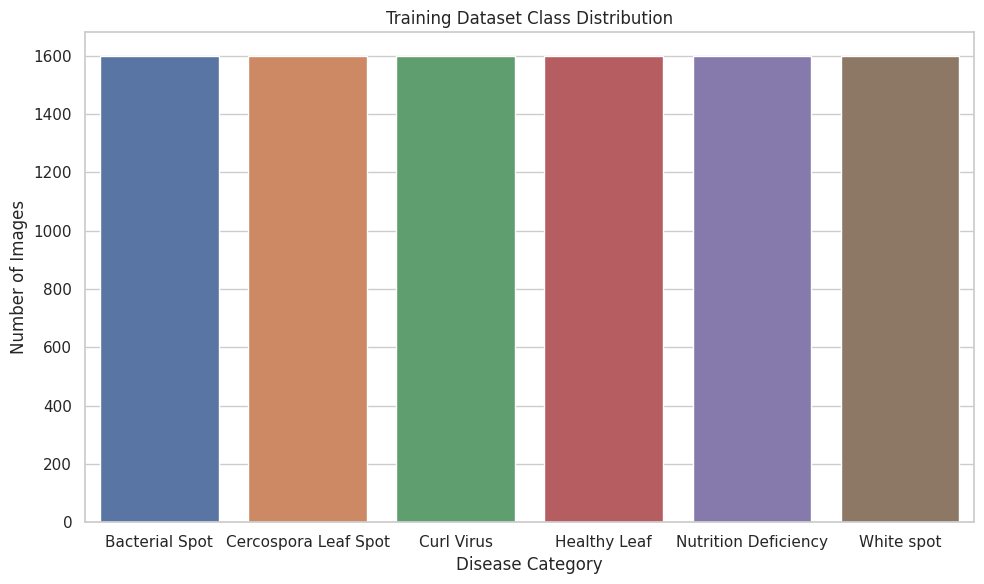

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = list(training_data.class_indices.keys())
class_counts = np.unique(training_data.classes, return_counts=True)[1]


plt.figure(figsize=(10, 6))
sns.barplot(x=class_names,y=class_counts,  hue=class_names, legend=False)

plt.title('Training Dataset Class Distribution')
plt.xlabel('Disease Category')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

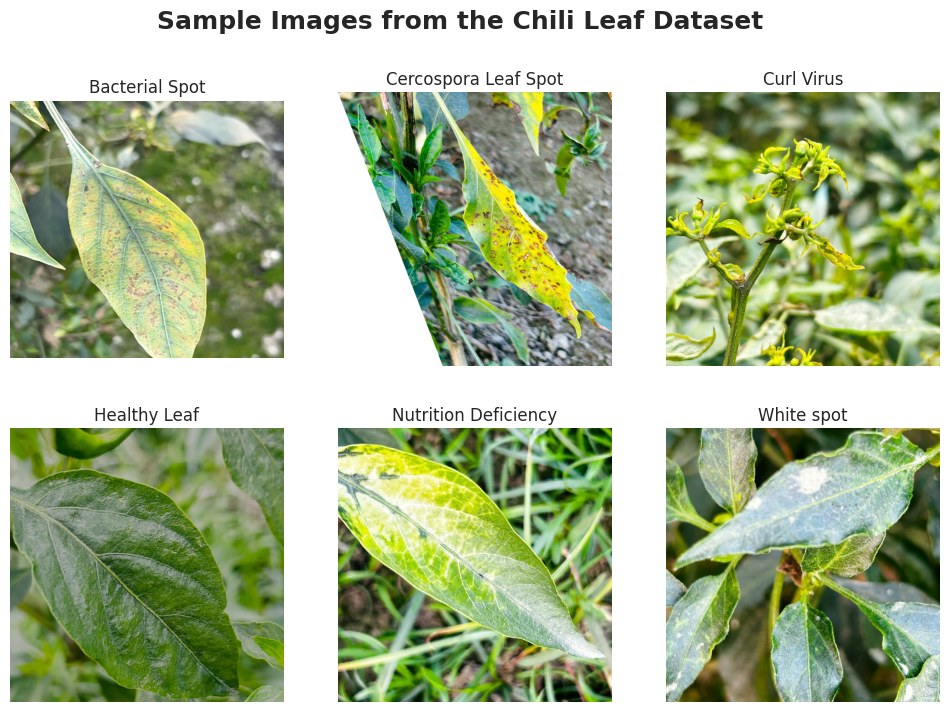

In [36]:
import os
import random
import matplotlib.image as mpimg

plt.figure(figsize=(12, 8))

for i, category in enumerate(class_names):
    folder_path = os.path.join(data_path, category)

    img_file = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_file)

    img = mpimg.imread(img_path)
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)

    plt.title(category)
    plt.axis('off')

plt.suptitle('Sample Images from the Chili Leaf Dataset', fontsize=18, fontweight='bold')
plt.show()

In [ ]:
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg16_base.trainable = False

vgg16_model = Sequential([
    vgg16_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

vgg16_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
vgg16_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
resnet50_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

resnet50_base.trainable = False

resnet50_model = Sequential([
    resnet50_base,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

resnet50_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
resnet50_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
print("--- Training VGG-16 ---")
vgg_history = vgg16_model.fit(training_data, validation_data=validation_data, epochs=15)

print("--- Training ResNet-50 ---")
resnet_history = resnet50_model.fit(training_data, validation_data=validation_data, epochs=15)

--- Training VGG-16 ---


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 149s 482ms/step - accuracy: 0.7171 - loss: 1.8504 - val_accuracy: 0.9229 - val_loss: 0.2226
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 144s 478ms/step - accuracy: 0.9564 - loss: 0.1258 - val_accuracy: 0.9325 - val_loss: 0.1986
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 205s 489ms/step - accuracy: 0.9727 - loss: 0.0761 - val_accuracy: 0.9458 - val_loss: 0.1792
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 145s 483ms/step - accuracy: 0.9831 - loss: 0.0504 - val_accuracy: 0.9546 - val_loss: 0.1527
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 146s 485ms/step - accuracy: 0.9862 - loss: 0.0400 - val_accuracy: 0.9371 - val_loss: 0.2015
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 147s 491ms/step - accuracy: 0.9873 - loss: 0.0352 - val_accuracy: 0.9371 - val_loss: 0.2262
Epoch 7/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 161s 536ms/step - accuracy: 0.9843 - loss: 0.0454 - val_accuracy: 0.9142 - val_loss: 0.3252
Epoch 8/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 145s 484ms/step - accuracy: 0.9848 -

In [ ]:
print("VGG-16 Model Results")
print(f"Final Accuracy: {vgg_history.history['accuracy'][14]*100:.2f}%")
print(f'Final loss: {vgg_history.history['loss'][14]}')
print(f'Final Accuracy with validation data: {vgg_history.history['val_accuracy'][14]*100:.2f}%')
print(f'Final loss with validation data: {vgg_history.history['val_loss'][14]}')

VGG-16 Model Results
Final Accuracy: 98.89%
Final loss: 0.025991111993789673
Final Accuracy with validation data: 96.46%
Final loss with validation data: 0.1772526055574417


In [ ]:
print("Resnet-50 Model Results")
print(f'Final Accuracy: {resnet_history.history['accuracy'][14]*100:.2f}%')
print(f'Final loss: {resnet_history.history['loss'][14]}')
print(f'Final Accuracy with validation data: {resnet_history.history['val_accuracy'][14]*100:.2f}%')
print(f'Final loss with validation data: {resnet_history.history['val_loss'][14]}')

Resnet-50 Model Results
Final Accuracy: 98.89%
Final loss: 0.026079699397087097
Final Accuracy with validation data: 96.42%
Final loss with validation data: 0.3054528832435608


In [ ]:
# from google.colab import files

# vgg16_model.save('vgg16_chili.keras')
# print("Saved VGG-16")

# resnet50_model.save('resnet50_chili.keras')
# print("Saved ResNet-50")

# files.download('vgg16_chili.keras')
# files.download('resnet50_chili.keras')

Saved VGG-16
Saved ResNet-50


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>